# Training with 2D slices from volumes

This tutorial shows how to train a network with 2D samples from 3D inputs.

It mainly demonstrates 2d slice dataset using `monai.data.PatchIterd` and `monai.data.GridPatchDataset`.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Project-MONAI/tutorials/blob/main/modules/2d_slices_from_3d.ipynb)

## Setup environment

In [1]:
!python -c "import monai" || pip install -q "monai-weekly[tqdm, nibabel]"
%matplotlib inline

Traceback (most recent call last):
  File "<string>", line 1, in <module>
ModuleNotFoundError: No module named 'monai'
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 75.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 25.0 MB/s eta 0:00:00


## Setup imports

In [30]:
# Copyright (c) MONAI Consortium
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#     http://www.apache.org/licenses/LICENSE-2.0
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

import os
import tempfile
from glob import glob
import shutil

import matplotlib.pyplot as plt
import monai
import nibabel as nib
import numpy as np
import torch
from monai.data import DataLoader, create_test_image_3d
from monai.inferers import SliceInferer
from monai.metrics import DiceMetric
from monai.transforms import (
    Compose,
    EnsureChannelFirstd,
    EnsureTyped,
    LoadImaged,
    RandRotate90d,
    Resized,
    ScaleIntensityd,
    SqueezeDimd,
    AsDiscreted
)
from monai.visualize import matshow3d

monai.config.print_config()
monai.utils.set_determinism(0)

MONAI version: 1.5.dev2520
Numpy version: 2.0.2
Pytorch version: 2.6.0+cu124
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: cc43efa2f524c91686c29a51b04e31e47206dec8
MONAI __file__: /usr/local/lib/python3.11/dist-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: NOT INSTALLED or UNKNOWN VERSION.
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: 5.3.2
scikit-image version: 0.25.2
scipy version: 1.15.3
Pillow version: 11.2.1
Tensorboard version: 2.18.0
gdown version: 5.2.0
TorchVision version: 0.21.0+cu124
tqdm version: 4.67.1
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 5.9.5
pandas version: 2.2.2
einops version: 0.8.1
transformers version: 4.51.3
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT INSTALLED or UNKNOWN VERSION.
clearml version: NOT INSTALLED or UNKNOWN VERSION.

For details about installing the optional dependencies, please visit:
    https://docs.monai.io

## Setup data directory

You can specify a directory with the `MONAI_DATA_DIRECTORY` environment variable.  
This allows you to save results and reuse downloads.  
If not specified a temporary directory will be used.

In [31]:
import os

os.environ["MONAI_DATA_DIRECTORY"] = "/workspace/data/medical"
directory = os.environ.get("MONAI_DATA_DIRECTORY")
if directory is not None:
    os.makedirs(directory, exist_ok=True)
root_dir = tempfile.mkdtemp() if directory is None else directory
print(root_dir)

/workspace/data/medical


## Create a dataset

The example volumes are created with different spatial shapes for demo purposes


In [32]:
print(f"generating synthetic data to {root_dir} (this may take a while)")
for i in range(40):
    # make the input volumes different spatial shapes for demo purposes
    H, W, D = 30 + i, 40 + i, 50 + i
    channels = []
    #seg_channels = []
    for _ in range(3):
        img, segm = create_test_image_3d(
            H, W, D, num_seg_classes=1, channel_dim=-1, rad_max=10
        )
        channels.append(img)
        #seg_channels.append(segm)
    im = np.concatenate(channels, axis=-1)
    #seg = np.concatenate(seg_channels, axis=-1)
    #print(im.shape, segm.shape)
    unique_labels = np.unique(segm)

    # Create a dictionary for labelsx
    label_dict = {int(label): f"Class_{int(label)}" for label in unique_labels}

    n = nib.Nifti1Image(im, np.eye(4))
    nib.save(n, os.path.join(root_dir, f"img{i:d}.nii.gz"))
    n = nib.Nifti1Image(segm, np.eye(4))
    nib.save(n, os.path.join(root_dir, f"seg{i:d}.nii.gz"))

images = sorted(glob(os.path.join(root_dir, "img*.nii.gz")))
segs = sorted(glob(os.path.join(root_dir, "seg*.nii.gz")))

generating synthetic data to /workspace/data/medical (this may take a while)


In [33]:
print(label_dict)

{0: 'Class_0', 1: 'Class_1'}


In [34]:
train_files = [{"img": img, "seg": seg} for img, seg in zip(images[:35], segs[:35])]
val_files = [{"img": img, "seg": seg} for img, seg in zip(images[-3:], segs[-3:])]

In [35]:
print(train_files)

[{'img': '/workspace/data/medical/img0.nii.gz', 'seg': '/workspace/data/medical/seg0.nii.gz'}, {'img': '/workspace/data/medical/img1.nii.gz', 'seg': '/workspace/data/medical/seg1.nii.gz'}, {'img': '/workspace/data/medical/img10.nii.gz', 'seg': '/workspace/data/medical/seg10.nii.gz'}, {'img': '/workspace/data/medical/img11.nii.gz', 'seg': '/workspace/data/medical/seg11.nii.gz'}, {'img': '/workspace/data/medical/img12.nii.gz', 'seg': '/workspace/data/medical/seg12.nii.gz'}, {'img': '/workspace/data/medical/img13.nii.gz', 'seg': '/workspace/data/medical/seg13.nii.gz'}, {'img': '/workspace/data/medical/img14.nii.gz', 'seg': '/workspace/data/medical/seg14.nii.gz'}, {'img': '/workspace/data/medical/img15.nii.gz', 'seg': '/workspace/data/medical/seg15.nii.gz'}, {'img': '/workspace/data/medical/img16.nii.gz', 'seg': '/workspace/data/medical/seg16.nii.gz'}, {'img': '/workspace/data/medical/img17.nii.gz', 'seg': '/workspace/data/medical/seg17.nii.gz'}, {'img': '/workspace/data/medical/img18.nii.

## Volume-level preprocessing

In [37]:
# volume-level transforms for both image and segmentation
train_transforms = Compose(
    [
        LoadImaged(keys=["img", "seg"]),
        EnsureChannelFirstd(keys=["img", "seg"]),
        ScaleIntensityd(keys="img"),
        #Lambad(keys=['img', 'seg'], func=x: print(x.shape))
        RandRotate90d(keys=["img", "seg"], prob=0.5, spatial_axes=[0, 2]),
        EnsureTyped(keys=["img", "seg"]),
    ]
)
# 3D dataset with preprocessing transforms
volume_ds = monai.data.CacheDataset(data=train_files, transform=train_transforms)
# use batch_size=1 to check the volumes because the input volumes have different shapes
check_loader = DataLoader(volume_ds, batch_size=1)
check_data = monai.utils.misc.first(check_loader)
print("first volume's shape: ", check_data["img"].shape, check_data["seg"].shape)

Loading dataset: 100%|██████████| 35/35 [00:00<00:00, 44.43it/s]

first volume's shape:  torch.Size([1, 3, 30, 40, 50]) torch.Size([1, 1, 30, 40, 50])


## volume to patch processing

- define the 2d slice dataset using `monai.data.PatchIterd` and `monai.data.GridPatchDataset`
- patch-level preprocessing, resize the sampled slices to a consistent size so that we can batch
the last spatial dim is always 1, so we squeeze dim.

In [40]:
patch_func = monai.data.PatchIterd(
    keys=["img", "seg"],
    patch_size=(None, None, 1),  # dynamic first two dimensions
    start_pos=(0, 0, 0)
)
patch_transform = Compose(
    [
        SqueezeDimd(keys=["img", "seg"], dim=-1),  # squeeze the last dim
        Resized(keys=["img", "seg"], spatial_size=[48, 48]),
        AsDiscreted(keys=["seg"], dim=0, to_onehot=2)
        # to use crop/pad instead of reszie:
        # ResizeWithPadOrCropd(keys=["img", "seg"], spatial_size=[48, 48], mode="replicate"),
    ]
)
patch_ds = monai.data.GridPatchDataset(
    data=volume_ds, patch_iter=patch_func, transform=patch_transform, with_coordinates=False)
train_loader = DataLoader(
    patch_ds,
    batch_size=5,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)
check_data = monai.utils.misc.first(train_loader)
print("first volume's shape: ", check_data["img"].shape, check_data["seg"].shape)

first volume's shape:  torch.Size([5, 3, 48, 48]) torch.Size([5, 2, 48, 48])


## Define 2D network and losses

In [41]:
import torch
from transformers import Dinov2Model, Dinov2PreTrainedModel
from transformers.modeling_outputs import SemanticSegmenterOutput

class LinearClassifier(torch.nn.Module):
    def __init__(self, in_channels, num_labels=1):
        super(LinearClassifier, self).__init__()
        self.in_channels = in_channels
        self.classifier = torch.nn.Conv2d(in_channels, num_labels, (1, 1))

    def forward(self, embeddings):
        # The embeddings shape is [batch_size, num_patches + 1, hidden_size]
        # We need to remove the CLS token and reshape for the conv layer
        patch_embeddings = embeddings[:, 1:, :]  # Remove CLS token

        # Get batch size from input
        batch_size = embeddings.shape[0]

        # Assuming the patches form a 2D grid (e.g., 32x32 for Dinov2-base)
        # Calculate the grid size from the number of patches
        num_patches = patch_embeddings.shape[1]
        grid_size = int(num_patches ** 0.5)  # Assuming square grid

        # Reshape to [batch_size, grid_size, grid_size, hidden_size]
        patch_embeddings = patch_embeddings.reshape(batch_size, grid_size, grid_size, self.in_channels)

        # Permute to [batch_size, hidden_size, grid_size, grid_size] for Conv2d
        patch_embeddings = patch_embeddings.permute(0, 3, 1, 2)

        return self.classifier(patch_embeddings)


class Dinov2ForSemanticSegmentation(Dinov2PreTrainedModel):
    def __init__(self, config):
        super().__init__(config)
        self.dinov2 = Dinov2Model(config)
        self.classifier = LinearClassifier(config.hidden_size, config.num_labels)

    def forward(self, pixel_values, output_hidden_states=False, output_attentions=False, labels=None):
        # Get embeddings from frozen features
        outputs = self.dinov2(pixel_values,
                            output_hidden_states=output_hidden_states,
                            output_attentions=output_attentions)

        # Get the patch embeddings (excluding CLS token)
        patch_embeddings = outputs.last_hidden_state[:, 1:, :]

        # Convert to logits and upsample to the size of the pixel values
        logits = self.classifier(outputs.last_hidden_state)

        # Upsample to match input spatial dimensions
        logits = torch.nn.functional.interpolate(logits, size=pixel_values.shape[2:], mode="bilinear", align_corners=False)

        loss = None
        if labels is not None:
            loss_fct = monai.losses.DiceLoss(sigmoid=True)
            loss = loss_fct(logits, labels)

        return SemanticSegmenterOutput(
            loss=loss,
            logits=logits,
            hidden_states=outputs.hidden_states,
            attentions=outputs.attentions,
        )

In [42]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model = monai.networks.nets.UNet(
#     spatial_dims=2,
#     in_channels=1,
#     out_channels=1,
#     channels=(16, 32, 64, 128),
#     strides=(2, 2, 2),
#     num_res_units=2,
# ).to(device)
# loss_function = monai.losses.DiceLoss(sigmoid=True)
# optimizer = torch.optim.Adam(model.parameters(), 5e-3)

In [43]:
model = Dinov2ForSemanticSegmentation.from_pretrained("facebook/dinov2-base", id2label=label_dict, num_labels=len(label_dict))

Some weights of Dinov2ForSemanticSegmentation were not initialized from the model checkpoint at facebook/dinov2-base and are newly initialized: ['classifier.classifier.bias', 'classifier.classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [44]:
for name, param in model.named_parameters():
  if name.startswith("dinov2"):
    param.requires_grad = False

In [45]:
batch = next(iter(train_loader))
print(batch['img'].shape, batch['seg'].unique())

torch.Size([5, 3, 48, 48]) metatensor([0., 1.])


In [46]:
outputs = model(pixel_values=batch["img"], labels=batch["seg"])
print(outputs.logits.shape)
print(outputs.loss)

torch.Size([5, 2, 48, 48])
metatensor(0.7543, grad_fn=<AliasBackward0>)


## The training loop

In [47]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Dinov2ForSemanticSegmentation.from_pretrained("facebook/dinov2-base", id2label=label_dict, num_labels=len(label_dict)).to(device)
for name, param in model.named_parameters():
  if name.startswith("dinov2"):
    param.requires_grad = False
loss_function = monai.losses.DiceLoss(sigmoid=True)
optimizer = torch.optim.Adam(model.parameters(), 5e-3)

Some weights of Dinov2ForSemanticSegmentation were not initialized from the model checkpoint at facebook/dinov2-base and are newly initialized: ['classifier.classifier.bias', 'classifier.classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [48]:
epoch_loss_values = []
num_epochs = 5
for epoch in range(num_epochs):
    print("-" * 10)
    print(f"epoch {epoch + 1}/{num_epochs}")
    model.train()
    epoch_loss, step = 0, 0
    for batch_data in train_loader:
        step += 1
        inputs, labels = batch_data["img"].to(device), batch_data["seg"].to(device)
        optimizer.zero_grad()
        outputs = model(pixel_values=inputs, labels=labels)
        loss = loss_function(outputs.logits, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        if step % 200 == 0:
            print(f"{step}, train_loss: {loss.item():.4f}")
    epoch_loss /= step
    epoch_loss_values.append(epoch_loss)
    print(f"epoch {epoch + 1} average loss: {epoch_loss:.4f}")
print("train completed")

----------
epoch 1/5
200, train_loss: 0.4834
400, train_loss: 0.4902
epoch 1 average loss: 0.3755
----------
epoch 2/5
200, train_loss: 0.2020
400, train_loss: 0.4117
epoch 2 average loss: 0.3177
----------
epoch 3/5
200, train_loss: 0.0000
400, train_loss: 0.4774
epoch 3 average loss: 0.3083
----------
epoch 4/5
200, train_loss: 0.3603
400, train_loss: 0.3664
epoch 4 average loss: 0.2976
----------
epoch 5/5
200, train_loss: 0.3709
400, train_loss: 0.4819
epoch 5 average loss: 0.2944
train completed


## SliceInferer

Dice:  tensor(0.9089)


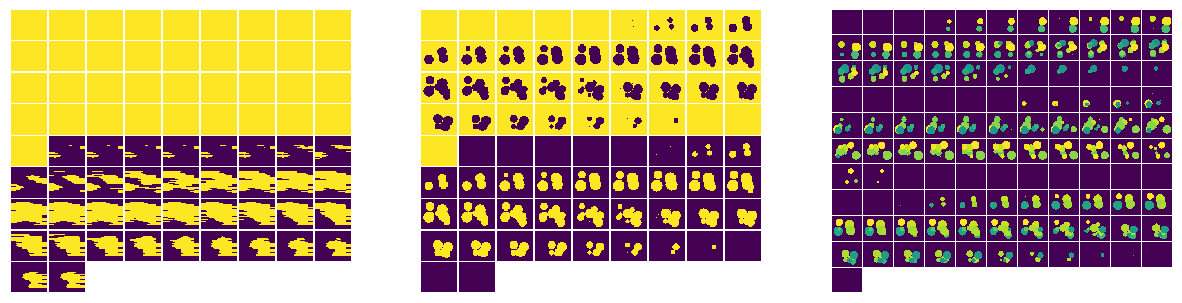

Dice:  tensor(0.9200)


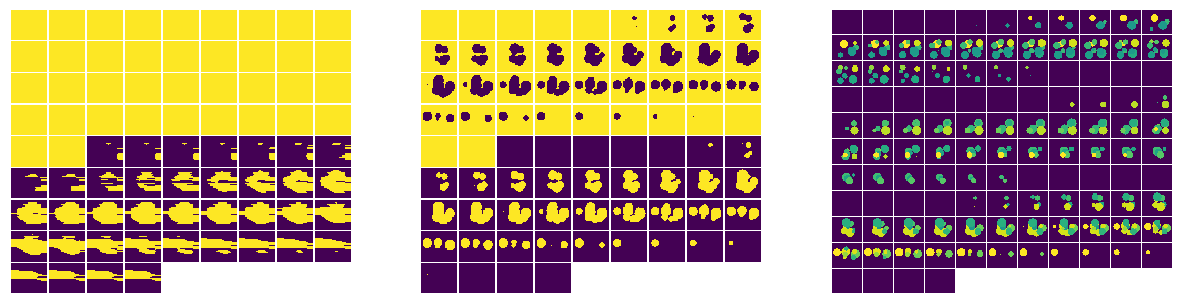

Dice:  tensor(0.9222)


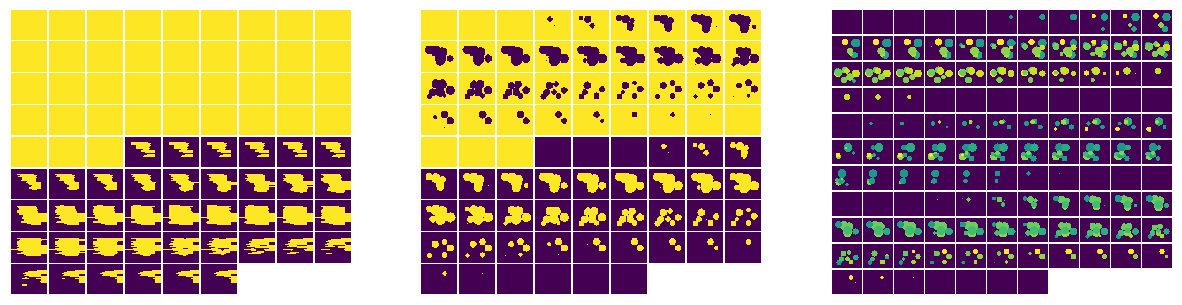

Avg Dice: 0.7416673302650452


In [61]:
val_transform = Compose(
    [
        LoadImaged(keys=["img", "seg"]),
        EnsureChannelFirstd(keys=["img", "seg"]),
        ScaleIntensityd(keys="img"),
        EnsureTyped(keys=["img", "seg"]),
        AsDiscreted(keys='seg', dim=0, to_onehot=2)
    ]
)
val_files = [{"img": img, "seg": seg} for img, seg in zip(images[-3:], segs[-3:])]
val_ds = monai.data.Dataset(data=val_files, transform=val_transform)
data_loader = DataLoader(val_ds, num_workers=1, pin_memory=torch.cuda.is_available())
dice_metric = DiceMetric(include_background=True, reduction="mean", get_not_nans=False)
model.eval()
with torch.no_grad():
    for val_data in data_loader:
        val_images = val_data["img"].to(device)
        val_gt = val_data['seg'].to(device)#.argmax(1, keepdims=True)
        #print(val_gt.shape)
        roi_size = (48, 48)
        sw_batch_size = 5
        slice_inferer = SliceInferer(
            roi_size=roi_size,
            sw_batch_size=sw_batch_size,
            spatial_dim=1,  # Spatial dim to slice along is defined here
            device=torch.device("cpu"),
            padding_mode="replicate",
        )
        val_output = slice_inferer(val_images, model)
        val_output_tensor = val_output["logits"]  # change to your actual key if needed
        val_pred = torch.sigmoid(val_output_tensor) > 0.5
        val_gt_thres = torch.sigmoid(val_gt) > 0.5
        dice_metric(y_pred=val_pred, y=val_gt_thres.cpu())
        print("Dice: ", dice_metric.get_buffer()[-1][0])
        fig = plt.figure(figsize=(15, 10))
        plt.subplot(1, 3, 1)
        matshow3d(val_pred[0], fig=plt.gca())  # <- Fixed line
        plt.subplot(1, 3, 2)
        matshow3d(val_gt[0], fig=plt.gca())
        plt.subplot(1, 3, 3)
        matshow3d(val_images[0], fig=plt.gca())
        plt.show()
    print(f"Avg Dice: {dice_metric.aggregate().item()}")

## Cleanup data directory

Remove directory if a temporary was used.

In [ ]:
if directory is None:
    shutil.rmtree(root_dir)